# Fraud Transaction Risk Intelligence
## 04 — Fraud Modelling

Train machine learning models to identify potentially fraudulent transactions using the engineered feature set.

### Pipeline Stage 4 — Fraud Modelling

Use engineered transaction, payment, identity and behavioural features to build fraud classification models.

In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)

## 1. Load Engineered Data

Load the feature set created in Notebook 3.

In [2]:
DATA_PATH = "../data/processed/train_featured.parquet"

train = pd.read_parquet(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", train.shape)

Dataset loaded successfully!
Shape: (590540, 455)


## 2. Prepare Features and Target

Separate the fraud target from the predictor variables.

In [3]:
TARGET = "isFraud"

X = train.drop(columns=[TARGET])
y = train[TARGET]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (590540, 454)
Target: (590540,)


In [4]:
print("Target distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(
    y.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Target percentage:
isFraud
0    96.5
1     3.5
Name: proportion, dtype: float64


## 3. Remove Identifier Columns

`TransactionID` uniquely identifies a transaction but does not represent a meaningful behavioural feature, so it is excluded from modelling.

In [5]:
if "TransactionID" in X.columns:
    X = X.drop(columns=["TransactionID"])

print("Feature count after removing identifiers:", X.shape[1])

Feature count after removing identifiers: 453


## 4. Prepare Time Features

The engineered time features are retained, while the original elapsed-time variable is removed to avoid redundant representations.

In [6]:
if "TransactionDT" in X.columns:
    X = X.drop(columns=["TransactionDT"])

## 5. Identify Feature Types

Separate numerical and categorical features so that each can be processed appropriately.

In [7]:
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 421
Categorical features: 31


## 6. Select Categorical Features

Only selected low-cardinality categorical features are one-hot encoded. High-cardinality variables are excluded from this modelling pipeline to control memory usage.

In [8]:
preferred_categorical = [
    "ProductCD",
    "card4",
    "card6",
    "DeviceType"
]

categorical_features = [
    col for col in preferred_categorical
    if col in X.columns
]

numeric_features = [
    col for col in X.columns
    if col not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:", len(numeric_features))

Categorical features:
['ProductCD', 'card4', 'card6', 'DeviceType']

Numerical features: 448


## 7. Chronological Train-Test Split

Transactions are split chronologically to better reflect how a fraud model would be used in production, where future transactions should not influence past training data.

In [9]:
sort_index = train["TransactionDT"].sort_values().index

X = X.loc[sort_index]
y = y.loc[sort_index]

split_point = int(len(X) * 0.80)

X_train = X.iloc[:split_point].copy()
X_test = X.iloc[split_point:].copy()

y_train = y.iloc[:split_point].copy()
y_test = y.iloc[split_point:].copy()

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining fraud rate:", y_train.mean())
print("Test fraud rate:", y_test.mean())

Training set: (472432, 452)
Test set: (118108, 452)

Training fraud rate: 0.03513521522674162
Test fraud rate: 0.034409184813899145


## 8. Select Modelling Features

The dataset contains hundreds of anonymized variables. To keep the modelling pipeline memory-efficient and interpretable, we use a focused set of engineered, transaction, payment and identity features.

In [10]:
model_features = [
    "TransactionAmt",
    "TransactionHour",
    "TransactionDay",
    "TransactionWeek",
    "LogTransactionAmt",
    "TransactionAmtDecimals",
    "AmountVsMedian",
    "AmountZScore",
    "MissingFeatureCount",
    "MissingFeatureRatio",
    "IdentityFeatureCount",
    "HasIdentityInfo",
    "HasDeviceInfo",
    "CardFeatureCount",
    "AddressFeatureCount",
    "ProductCD",
    "card4",
    "card6",
    "DeviceType",
    "P_emaildomain",
    "R_emaildomain"
]

model_features = [
    col for col in model_features
    if col in train.columns
]

X = train[model_features].copy()
y = train["isFraud"].copy()

print("Selected features:", len(model_features))
print(model_features)

Selected features: 21
['TransactionAmt', 'TransactionHour', 'TransactionDay', 'TransactionWeek', 'LogTransactionAmt', 'TransactionAmtDecimals', 'AmountVsMedian', 'AmountZScore', 'MissingFeatureCount', 'MissingFeatureRatio', 'IdentityFeatureCount', 'HasIdentityInfo', 'HasDeviceInfo', 'CardFeatureCount', 'AddressFeatureCount', 'ProductCD', 'card4', 'card6', 'DeviceType', 'P_emaildomain', 'R_emaildomain']


In [11]:
sort_index = train["TransactionDT"].sort_values().index

X = X.loc[sort_index]
y = y.loc[sort_index]

split_point = int(len(X) * 0.80)

X_train = X.iloc[:split_point].copy()
X_test = X.iloc[split_point:].copy()

y_train = y.iloc[:split_point].copy()
y_test = y.iloc[split_point:].copy()

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (472432, 21)
Test set: (118108, 21)


In [12]:
categorical_features = [
    col for col in [
        "ProductCD",
        "card4",
        "card6",
        "DeviceType",
        "P_emaildomain",
        "R_emaildomain"
    ]
    if col in X.columns
]

numeric_features = [
    col for col in X.columns
    if col not in categorical_features
    and pd.api.types.is_numeric_dtype(X[col])
]

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 15
Categorical features: 6


In [13]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

## 9. Logistic Regression

Train a class-balanced Logistic Regression model as the baseline fraud classifier.

In [14]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=300,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


## 10. Logistic Regression Predictions

Generate fraud probabilities and final classifications for the test period.

In [15]:
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

logistic_pred = (
    logistic_prob >= 0.5
).astype(int)

print("Predictions generated successfully.")

Predictions generated successfully.


## 11. Logistic Regression Metrics

Evaluate the baseline model using fraud-focused classification metrics.

In [16]:
logistic_metrics = {
    "Model": "Logistic Regression",
    "Precision": precision_score(y_test, logistic_pred),
    "Recall": recall_score(y_test, logistic_pred),
    "F1": f1_score(y_test, logistic_pred),
    "ROC_AUC": roc_auc_score(y_test, logistic_prob),
    "PR_AUC": average_precision_score(y_test, logistic_prob)
}

logistic_metrics

{'Model': 'Logistic Regression',
 'Precision': 0.06619660607628781,
 'Recall': 0.7554133858267716,
 'F1': 0.12172637338672905,
 'ROC_AUC': 0.7757073299102404,
 'PR_AUC': 0.14437700050998}

In [17]:
print(classification_report(
    y_test,
    logistic_pred,
    digits=4
))

              precision    recall  f1-score   support

           0     0.9861    0.6203    0.7615    114044
           1     0.0662    0.7554    0.1217      4064

    accuracy                         0.6249    118108
   macro avg     0.5262    0.6878    0.4416    118108
weighted avg     0.9545    0.6249    0.7395    118108



## 12. Random Forest

Train a class-balanced Random Forest model to capture non-linear relationships between transaction characteristics and fraud risk.

In [18]:
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


## 13. Random Forest Predictions

Generate fraud probabilities and classifications for the test period.

In [19]:
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

rf_pred = (
    rf_prob >= 0.5
).astype(int)

print("Random Forest predictions generated successfully.")

Random Forest predictions generated successfully.


## 14. Random Forest Metrics

Evaluate the Random Forest using fraud-focused classification metrics.

In [20]:
rf_metrics = {
    "Model": "Random Forest",
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1": f1_score(y_test, rf_pred),
    "ROC_AUC": roc_auc_score(y_test, rf_prob),
    "PR_AUC": average_precision_score(y_test, rf_prob)
}

rf_metrics

{'Model': 'Random Forest',
 'Precision': 0.09818899985094649,
 'Recall': 0.6483759842519685,
 'F1': 0.17055016181229773,
 'ROC_AUC': 0.7960036160842879,
 'PR_AUC': 0.19958645133603584}

In [21]:
print(classification_report(
    y_test,
    rf_pred,
    digits=4
))

              precision    recall  f1-score   support

           0     0.9843    0.7878    0.8752    114044
           1     0.0982    0.6484    0.1706      4064

    accuracy                         0.7830    118108
   macro avg     0.5413    0.7181    0.5229    118108
weighted avg     0.9539    0.7830    0.8509    118108



## 15. Model Comparison

Compare the two models using precision, recall, F1-score, ROC-AUC and PR-AUC.

In [22]:
results = pd.DataFrame([
    logistic_metrics,
    rf_metrics
])

results

,Model,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.066197,0.755413,0.121726,0.775707,0.144377
1,Random Forest,0.098189,0.648376,0.170550,0.796004,0.199586


## 16. Performance Comparison

Visualize the main evaluation metrics across the two models.

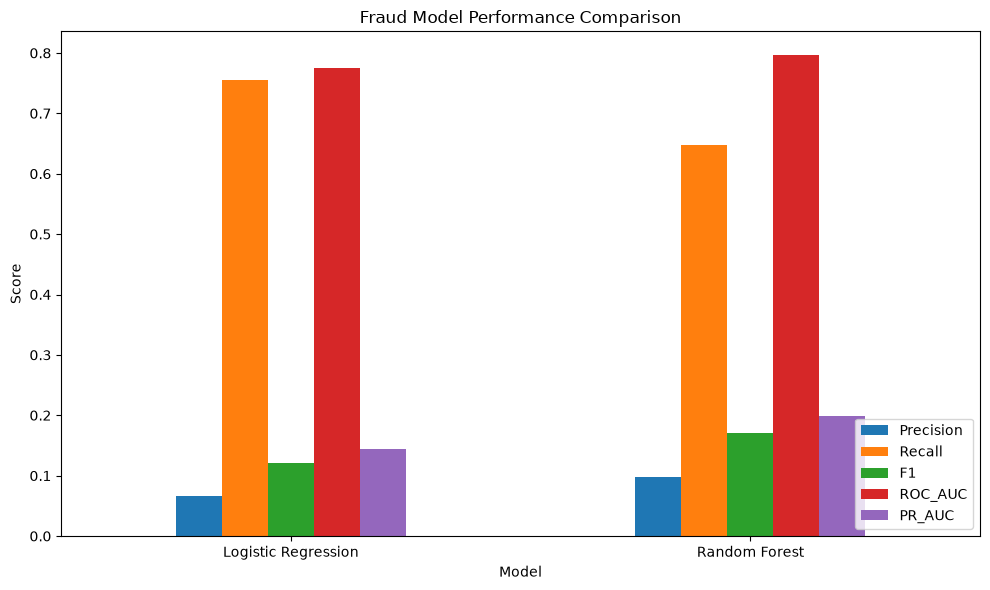

In [23]:
metrics_to_plot = [
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",
    "PR_AUC"
]

results.set_index("Model")[metrics_to_plot].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Fraud Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()

plt.show()

## 17. Confusion Matrix

Examine the Random Forest classification errors, with particular attention to missed fraudulent transactions.

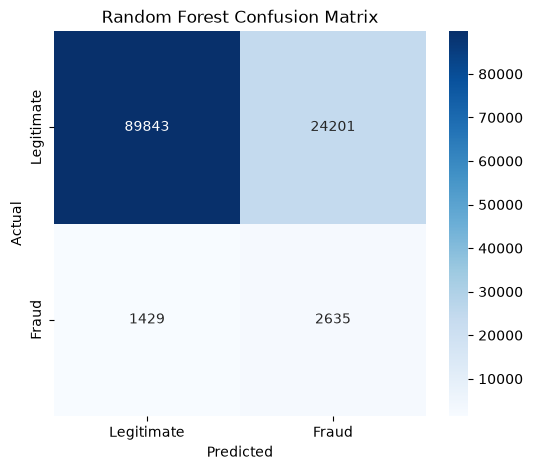

In [24]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 18. Feature Importance

Identify the features contributing most strongly to the Random Forest predictions.

In [25]:
rf_estimator = random_forest_model.named_steps["model"]
fitted_preprocessor = random_forest_model.named_steps["preprocessor"]

feature_names = fitted_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_estimator.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
5,numeric__TransactionAmtDecimals,0.117363
9,numeric__MissingFeatureRatio,0.068765
15,categorical__ProductCD_C,0.066397
19,categorical__ProductCD_W,0.062235
10,numeric__IdentityFeatureCount,0.061559
8,numeric__MissingFeatureCount,0.052260
30,categorical__DeviceType_Unknown,0.048323
28,categorical__card6_debit,0.042201
3,numeric__TransactionWeek,0.039919
2,numeric__TransactionDay,0.039302


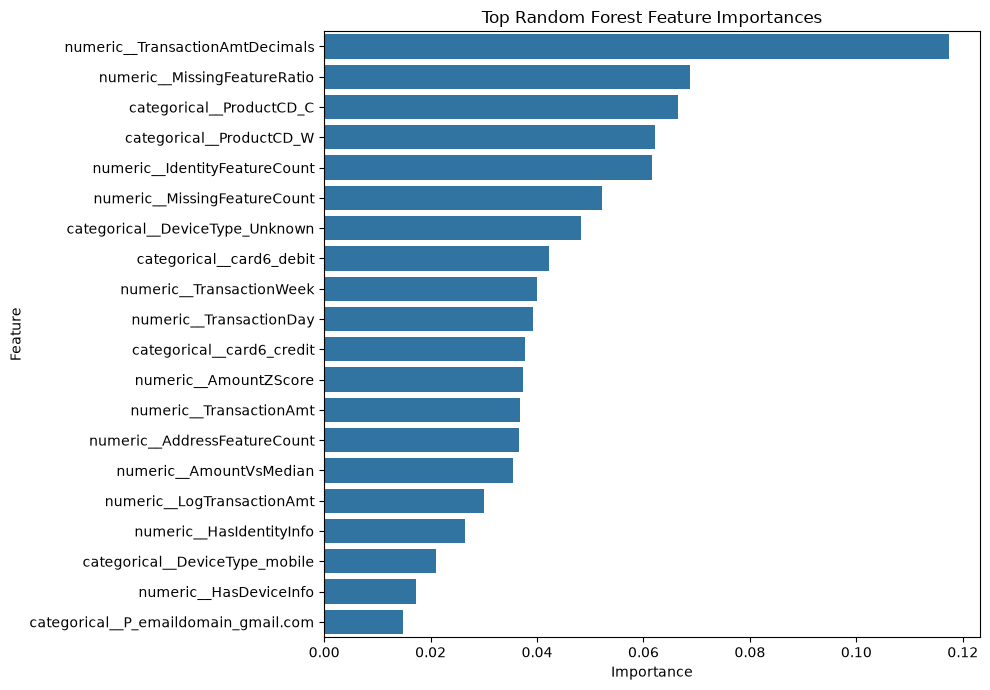

In [26]:
top_importance = feature_importance.head(20)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_importance,
    x="Importance",
    y="Feature"
)

plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 19. Save Model Predictions

Save test-set predictions so model evaluation and risk analysis can be performed without retraining the models.

In [27]:
OUTPUT_PATH = "../data/processed"

os.makedirs(OUTPUT_PATH, exist_ok=True)

predictions = pd.DataFrame({
    "TransactionIndex": X_test.index,
    "ActualFraud": y_test.values,
    "LogisticRegression_Probability": logistic_prob,
    "LogisticRegression_Prediction": logistic_pred,
    "RandomForest_Probability": rf_prob,
    "RandomForest_Prediction": rf_pred
})

predictions.to_parquet(
    os.path.join(
        OUTPUT_PATH,
        "model_predictions.parquet"
    ),
    index=False
)

print("Model predictions saved successfully!")

Model predictions saved successfully!


## 20. Save Model Results

Save the initial model comparison for use in the model evaluation stage.

In [28]:
results.to_csv(
    os.path.join(
        OUTPUT_PATH,
        "model_results.csv"
    ),
    index=False
)

print("Model results saved successfully!")

Model results saved successfully!


## 21. Modelling Summary

Two fraud classification models were trained using a chronological test split and evaluated using fraud-focused metrics.

The predictions and model results are saved for detailed evaluation in the next pipeline stage.

# Conclusion

The modelling stage produced baseline and ensemble fraud classifiers and generated predictions for the test period.

The next stage will evaluate model performance in greater detail and determine the most appropriate model and classification threshold for fraud detection.

In [29]:
print("Final modelling dataset shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nSaved files:")
print("train_featured.parquet")
print("model_predictions.parquet")
print("model_results.csv")

Final modelling dataset shapes:
X_train: (472432, 21)
X_test : (118108, 21)

Saved files:
train_featured.parquet
model_predictions.parquet
model_results.csv
